<a href="https://colab.research.google.com/github/ankitta-singh/machinelearning/blob/main/04_Decision_Tree_pruned_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques (1).zip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import zipfile
with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", "r") as zip_ref:
    zip_ref.extractall("house_data")


In [ ]:
df = pd.read_csv("house_data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 80)
y shape: (1460,)


In [ ]:
X = X.select_dtypes(include=np.number)
print("numerical Feature:", X.shape[1])


numerical Feature: 37


In [ ]:
print("missing value:", X.isnull().sum().sum())

missing value: 348


In [ ]:
X = X.fillna(X.median())
print("missing value:", X.isnull().sum().sum())

missing value: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)
print("training data:", X_train.shape)
print("testing data:", X_test.shape)


training data: (1168, 37)
testing data: (292, 37)


In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [ ]:
print("TRAINING PERFORMANCE")
print("="* 40)
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))

TRAINING PERFORMANCE
MAE: 0.0
MSE: 0.0
RMSE: 0.0
R2: 1.0


In [ ]:
print("TESTING PERFORMANCE")
print("="* 40)
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

TESTING PERFORMANCE
MAE: 27002.59931506849
MSE: 1669351626.1815069
RMSE: 40857.69971720761


In [ ]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of alpha values:", len(ccp_alphas))
print(ccp_alphas[:10])

Number of alpha values: 1101
[0.         0.09631849 1.07020548 1.07020548 4.28082192 4.28082192
 4.28082192 4.28082192 4.28082192 4.28082192]


In [ ]:
trees = []

for alpha in ccp_alphas:
    tree = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )
    tree.fit(X_train, y_train)
    trees.append(tree)

print("Trees created:", len(trees))

Trees created: 1101


In [ ]:
train_scores = []
test_scores = []

for tree in trees:
    train_scores.append(
        r2_score(y_train, tree.predict(X_train))
    )

    test_scores.append(
        r2_score(y_test, tree.predict(X_test))
    )

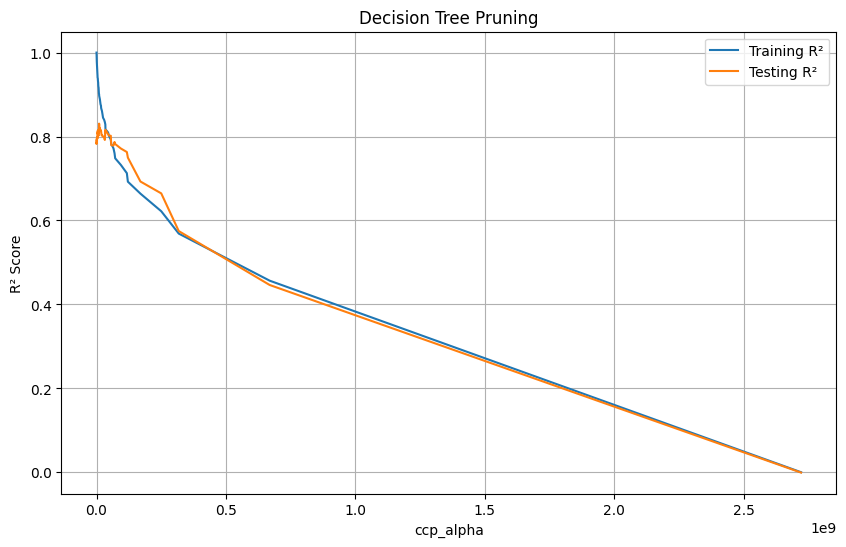

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(ccp_alphas, train_scores, label="Training R²")
plt.plot(ccp_alphas, test_scores, label="Testing R²")

plt.xlabel("ccp_alpha")
plt.ylabel("R² Score")
plt.title("Decision Tree Pruning")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_index = np.argmax(test_scores)

In [ ]:
best_alpha = ccp_alphas[best_index]
best_test_r2 = test_scores[best_index]
print("best ccp_alpha:", best_alpha)
print("best test r2:", best_test_r2)
print("training r2:", train_scores[best_index])


best ccp_alpha: 10071658.239421643
best test r2: 0.8306723123076329
training r2: 0.9004439400175593


In [ ]:
pruned_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=best_alpha
)
pruned_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=np.float64(10071658.239421643), random_state=42)

In [ ]:
y_train_pred_pruned = pruned_tree.predict(X_train)
y_test_pred_pruned = pruned_tree.predict(X_test)

In [ ]:
print("PRUNED DECISION TREE")
print("=" * 40)

print("TRAINING")
print("MAE :", mean_absolute_error(y_train, y_train_pred_pruned))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_pruned)))
print("R2  :", r2_score(y_train, y_train_pred_pruned))

print("\nTESTING")
print("MAE :", mean_absolute_error(y_test, y_test_pred_pruned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_pruned)))
print("R2  :", r2_score(y_test, y_test_pred_pruned))

PRUNED DECISION TREE
TRAINING
MAE : 18438.517770125436
RMSE: 24368.158227012587
R2  : 0.9004439400175593

TESTING
MAE : 24899.57643829452
RMSE: 36038.848490332755
R2  : 0.8306723123076329


In [ ]:
print("Tree depth:", pruned_tree.get_depth())
print("Number of leaves:", pruned_tree.get_n_leaves())
print("Number of nodes:", pruned_tree.tree_.node_count)

Tree depth: 7
Number of leaves: 41
Number of nodes: 81


In [ ]:
print("UNPRUNED TREE")
print("Depth:", dt.get_depth())
print("Leaves:", dt.get_n_leaves())
print("Nodes:", dt.tree_.node_count)

print("\nPRUNED TREE")
print("Depth:", pruned_tree.get_depth())
print("Leaves:", pruned_tree.get_n_leaves())
print("Nodes:", pruned_tree.tree_.node_count)

UNPRUNED TREE
Depth: 23
Leaves: 1124
Nodes: 2247

PRUNED TREE
Depth: 7
Leaves: 41
Nodes: 81
